# 8장. 텍스트 빈도 분석 (1)영어단어분석

In [1]:
! pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### - 자연어처리패키지 nltk download

In [ ]:
#파이썬에서 자연어를 처리할 때 가장 많이 쓰이는 패키지
! pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 62.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ---------------- ----------------------- 2/5 [joblib]
   ------------------------ --------------- 3/5 [click]
   ------------------------ --------------- 3/5 [click]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   -------------------------------- ------- 4/5 [nltk]
   --------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import nltk

In [5]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

#### -----------------------------------------------------------------

# 4. 데이터 준비

In [2]:
import pandas as pd
import glob
import re
from functools import reduce

#토크나이저 모듈
from nltk.tokenize import word_tokenize
#불용어 처리
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
#단어 빈도 분석
from collections import Counter
#시각화
import matplotlib.pyplot as plt
#워드클라우드 시각화 모듈
from wordcloud import STOPWORDS, WordCloud

## 데이터 조합 – 파일 병합하기

In [3]:
# glob : 사용자가 제시한 조건에 맞는 파일명을 리스트 형식으로 반환
all_files = glob.glob('./8장_data/myCabinetExcelData*.xlsx')
all_files #출력하여 내용 확인

['./8장_data\\myCabinetExcelData (1).xlsx',
 './8장_data\\myCabinetExcelData (2).xlsx',
 './8장_data\\myCabinetExcelData (3).xlsx',
 './8장_data\\myCabinetExcelData (4).xlsx',
 './8장_data\\myCabinetExcelData (5).xlsx',
 './8장_data\\myCabinetExcelData (6).xlsx',
 './8장_data\\myCabinetExcelData (7).xlsx',
 './8장_data\\myCabinetExcelData (8).xlsx',
 './8장_data\\myCabinetExcelData (9).xlsx',
 './8장_data\\myCabinetExcelData.xlsx']

In [4]:
#"ImportError: Missing optional dependency 'xlrd'." 에러 발생 시, xlrd 패키지 설치하기
! pip install xlrd


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#파이썬에서 엑셀 읽어들이기
! pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
all_files_data = [] #저장할 리스트
for file in all_files:
    data_frame = pd.read_excel(file) # read_excel 오류 발생, ! pip install openpyxl 커맨드로 해결
    all_files_data.append(data_frame)
    
all_files_data[0] #작업 내용 확인

,Unnamed: 0,번호,제목,저자,출판사,출판일
0,NaN,1,Call for Special Issue Papers: Soft Computing ...,"Chilamkurti, Naveen; Paul, Anand; Kumar, Akshi",Mary Ann Leibert,2020
1,NaN,2,"Big Data, Efficient Markets, and the End of Da...","Urbaczewski, Andrew; Elmore, Ryan",Mary Ann Leibert,2018
2,NaN,3,Big Data and Predictive Analytics in Health Care,unknown,Mary Ann Leibert,2014
3,NaN,4,Call for Special Issue Papers: Internet of Med...,"Din, Sadia; Aslan, Nauman; Cheung, Simon K.S.;...",Mary Ann Leibert,2020
4,NaN,5,Big Data Literature Search,unknown,Mary Ann Leibert,2014
...,...,...,...,...,...,...
95,NaN,96,A survey on big data processing infrastructure...,"Nunna, Krishna Chaitanya; Mehdipour, Farhad; T...",Inderscience,2015
96,NaN,97,Toward Efficient and Flexible Metadata Indexin...,"Zhao, D.; Qiao, K.; Zhou, Z.; Li, T.; Lu, Z.; ...",unknown,2017
97,NaN,98,Distributed Feature Selection for Efficient Ec...,"Zhao, L.; Chen, Z.; Hu, Y.; Min, G.; Jiang, Z.",unknown,2018
98,NaN,99,A platform for big data analytics on distribut...,"Aye, Kyar Nyo; Thein, Thandar",Inderscience,2015


In [7]:
all_files_data_concat = pd.concat( all_files_data, axis = 0, ignore_index = True)
all_files_data_concat #출력하여 내용 확인

,Unnamed: 0,번호,제목,저자,출판사,출판일
0,NaN,1,Call for Special Issue Papers: Soft Computing ...,"Chilamkurti, Naveen; Paul, Anand; Kumar, Akshi",Mary Ann Leibert,2020
1,NaN,2,"Big Data, Efficient Markets, and the End of Da...","Urbaczewski, Andrew; Elmore, Ryan",Mary Ann Leibert,2018
2,NaN,3,Big Data and Predictive Analytics in Health Care,unknown,Mary Ann Leibert,2014
3,NaN,4,Call for Special Issue Papers: Internet of Med...,"Din, Sadia; Aslan, Nauman; Cheung, Simon K.S.;...",Mary Ann Leibert,2020
4,NaN,5,Big Data Literature Search,unknown,Mary Ann Leibert,2014
...,...,...,...,...,...,...
995,NaN,96,Big data analysis of swimming pools' impact on...,"Elnakat, Afamia; Gomez, Juan D.; Roberts, Jaso...",Inderscience,2015
996,NaN,97,MonkeyKing: Adaptive Parameter Tuning on Big D...,"Du, Haizhou; Han, Ping; Xiang, Qiao; Huang, Sheng",Mary Ann Leibert,2020
997,NaN,98,Curating Big Data Made Simple: Perspectives fr...,unknown,Mary Ann Leibert,2014
998,NaN,99,Big Data 2.0: Cataclysm or Catalyst?,unknown,Mary Ann Leibert,2014


In [8]:
all_files_data_concat.to_csv( '8장_data/riss_bigdata.csv', encoding = 'utf-8', index = False)

## 데이터 전처리

In [9]:
#수집한 데이터에서 제목을 추출하여 전처리를 수행
all_title = all_files_data_concat['제목']
all_title #출력하여 내용 확인

0      Call for Special Issue Papers: Soft Computing ...
1      Big Data, Efficient Markets, and the End of Da...
2       Big Data and Predictive Analytics in Health Care
3      Call for Special Issue Papers: Internet of Med...
4                             Big Data Literature Search
                             ...                        
995    Big data analysis of swimming pools' impact on...
996    MonkeyKing: Adaptive Parameter Tuning on Big D...
997    Curating Big Data Made Simple: Perspectives fr...
998                 Big Data 2.0: Cataclysm or Catalyst?
999    Does Medical School Training Relate to Practic...
Name: 제목, Length: 1000, dtype: object

In [10]:
#stopwords 함수에서 데이터 판단에 불필요한 단어 세트 불러오기
stopWords = set(stopwords.words("english"))
lemma = WordNetLemmatizer() #어간 추출기(레마)

In [15]:
stopWords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [16]:
lemma

<WordNetLemmatizer>

In [11]:
words = []
for title in all_title:
    #정규식 사용, 알파벳 제외한 모든 것 공백으로 치환
    EnWords = re.sub(r"[^a-zA-Z]+", " ", str(title))
    
    #소문자로 모두 변환 후 단어 분리
    EnWordsToken = word_tokenize(EnWords.lower())
    
    #EnwordsToken에 있는 모든 요소들에 대하여 각 요소들이 stopWords에 있지 않다면 리스트에 넣어라
    EnWordsTokenStop = [ w for w in EnWordsToken if w not in stopWords]
    
    #lemmatize : 단어 형태를 원형으로 변환
    EnWordsTokenStopLemma = [ lemma.lemmatize(w) for w in EnWordsTokenStop]
    words.append(EnWordsTokenStopLemma)

In [18]:
EnWords

'Does Medical School Training Relate to Practice Evidence from Big Data'

In [19]:
print(words) #출력하여 내용 확인

[['call', 'special', 'issue', 'paper', 'soft', 'computing', 'model', 'big', 'data', 'internet', 'thing'], ['big', 'data', 'efficient', 'market', 'end', 'daily', 'fantasy', 'sport', 'know'], ['big', 'data', 'predictive', 'analytics', 'health', 'care'], ['call', 'special', 'issue', 'paper', 'internet', 'medical', 'thing', 'big', 'data', 'pervasive', 'medical', 'care'], ['big', 'data', 'literature', 'search'], ['big', 'data', 'ensemble', 'clinical', 'prediction', 'healthcare', 'data', 'using', 'deep', 'learning', 'model'], ['call', 'special', 'issue', 'paper', 'cloud', 'computing', 'big', 'data', 'cognitive', 'iot'], ['call', 'special', 'issue', 'paper', 'big', 'data', 'analytics', 'industrial', 'intelligence'], ['u', 'army', 'person', 'event', 'data', 'environment', 'military', 'civilian', 'big', 'data', 'enterprise'], ['exploiting', 'reused', 'based', 'sharing', 'work', 'opportunity', 'big', 'data', 'multiquery', 'optimization', 'flink'], ['big', 'data', 'machine', 'analyze', 'stock', '

In [13]:
#리스트 2개일 경우 하나로 이어 붙여서 리스트 평탄화
words2 = list(reduce(lambda x, y: x+y, words))
print(words2) #출력하여 내용 확인

['call', 'special', 'issue', 'paper', 'soft', 'computing', 'model', 'big', 'data', 'internet', 'thing', 'big', 'data', 'efficient', 'market', 'end', 'daily', 'fantasy', 'sport', 'know', 'big', 'data', 'predictive', 'analytics', 'health', 'care', 'call', 'special', 'issue', 'paper', 'internet', 'medical', 'thing', 'big', 'data', 'pervasive', 'medical', 'care', 'big', 'data', 'literature', 'search', 'big', 'data', 'ensemble', 'clinical', 'prediction', 'healthcare', 'data', 'using', 'deep', 'learning', 'model', 'call', 'special', 'issue', 'paper', 'cloud', 'computing', 'big', 'data', 'cognitive', 'iot', 'call', 'special', 'issue', 'paper', 'big', 'data', 'analytics', 'industrial', 'intelligence', 'u', 'army', 'person', 'event', 'data', 'environment', 'military', 'civilian', 'big', 'data', 'enterprise', 'exploiting', 'reused', 'based', 'sharing', 'work', 'opportunity', 'big', 'data', 'multiquery', 'optimization', 'flink', 'big', 'data', 'machine', 'analyze', 'stock', 'market', 'sentiment',

# 5. 데이터 탐색 및 분석 모델 구축

## 1. 데이터 탐색 - 단어 빈도 구하기

In [14]:
count = Counter(words2)
count #출력하여 내용 확인

Counter({'data': 1239,
         'big': 1112,
         'analytics': 113,
         'based': 102,
         'analysis': 97,
         'driven': 71,
         'system': 62,
         'using': 56,
         'approach': 56,
         'issue': 48,
         'learning': 48,
         'model': 46,
         'challenge': 44,
         'application': 40,
         'new': 39,
         'special': 37,
         'management': 36,
         'framework': 36,
         'algorithm': 36,
         'call': 34,
         'research': 34,
         'science': 34,
         'platform': 34,
         'paper': 32,
         'health': 31,
         'cloud': 30,
         'era': 30,
         'opportunity': 28,
         'network': 27,
         'machine': 26,
         'mining': 26,
         'processing': 26,
         'technology': 26,
         'computing': 25,
         'performance': 25,
         'method': 25,
         'earth': 25,
         'optimization': 24,
         'perspective': 24,
         'business': 24,
         'smart': 24,
   

In [15]:
word_count = dict()

#tag : 각 단어
# 2글자 이상인 단어만 반복문 돌려서 각 단어가 몇번 나오는지
# most_common : 빈도수 가장 높은 50개만 반복

for tag, counts in count.most_common(50): # tag, counts <=> key, values
    if(len(str(tag))>1):
        word_count[tag] = counts
        print("%s : %d" % (tag, counts))

data : 1239
big : 1112
analytics : 113
based : 102
analysis : 97
driven : 71
system : 62
using : 56
approach : 56
issue : 48
learning : 48
model : 46
challenge : 44
application : 40
new : 39
special : 37
management : 36
framework : 36
algorithm : 36
call : 34
research : 34
science : 34
platform : 34
paper : 32
health : 31
cloud : 30
era : 30
opportunity : 28
network : 27
machine : 26
mining : 26
processing : 26
technology : 26
computing : 25
performance : 25
method : 25
earth : 25
optimization : 24
perspective : 24
business : 24
smart : 24
distributed : 23
information : 23
use : 23
review : 22
process : 22
world : 22
intelligence : 21
service : 21
development : 20


In [ ]:
word_count #딕셔너리에 잘 들어간 것 확인

{'data': 1239,
 'big': 1112,
 'analytics': 113,
 'based': 102,
 'analysis': 97,
 'driven': 71,
 'system': 62,
 'using': 56,
 'approach': 56,
 'issue': 48,
 'learning': 48,
 'model': 46,
 'challenge': 44,
 'application': 40,
 'new': 39,
 'special': 37,
 'management': 36,
 'framework': 36,
 'algorithm': 36,
 'call': 34,
 'research': 34,
 'science': 34,
 'platform': 34,
 'paper': 32,
 'health': 31,
 'cloud': 30,
 'era': 30,
 'opportunity': 28,
 'network': 27,
 'machine': 26,
 'mining': 26,
 'processing': 26,
 'technology': 26,
 'computing': 25,
 'performance': 25,
 'method': 25,
 'earth': 25,
 'optimization': 24,
 'perspective': 24,
 'business': 24,
 'smart': 24,
 'distributed': 23,
 'information': 23,
 'use': 23,
 'review': 22,
 'process': 22,
 'world': 22,
 'intelligence': 21,
 'service': 21,
 'development': 20}

## 2. 데이터 탐색 - 히스토그램 그리기

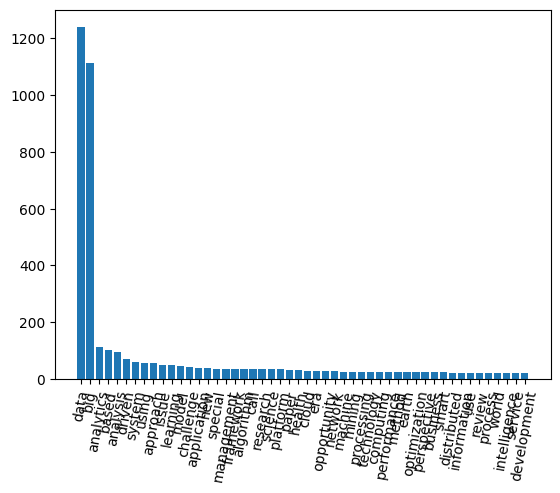

In [21]:
sorted_Keys = sorted(word_count, key = word_count.get, reverse = True)  #행
sorted_Values = sorted(word_count.values(), reverse = True)             #열

#차트에 데이터 삽입
plt.bar(range(len(word_count)), sorted_Values, align = 'center')

#x축 칼럼명 지정
plt.xticks(range(len(word_count)), list(sorted_Keys), rotation = 80)
plt.show()

###  - 'big', 'data'를 제외하고, 단어빈도 히스토그램 그리기

In [23]:
word_count2 = word_count
del word_count2['big']
del word_count2['data']

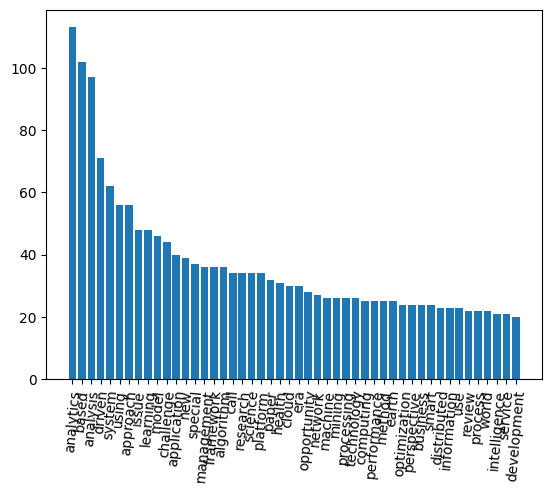

In [25]:
sorted_Keys = sorted(word_count2, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count2.values(), reverse = True)
plt.bar(range(len(word_count2)), sorted_Values, align = 'center')
plt.xticks( range(len(word_count2)), list(sorted_Keys), rotation = 85)
plt.show()

# 6. 결과 시각화

In [27]:
#추후 데이터가 몇번 나왔는지 카운트 하기 위해 doc_count라는 새로운 칼럼 만들어서 0 채워넣음
#자주 사용하는 기법
all_files_data_concat['doc_count'] = 0
summary_year = all_files_data_concat.groupby('출판일', as_index = False)['doc_count'].count()
summary_year #출력하여 내용 확인

,출판일,doc_count
0,2003,1
1,2004,1
2,2011,5
3,2012,19
4,2013,50
5,2014,124
6,2015,92
7,2016,112
8,2017,129
9,2018,118


In [26]:
#word cloud를 위해 이미지를 불러오는데 사용
import numpy as np
from PIL import *

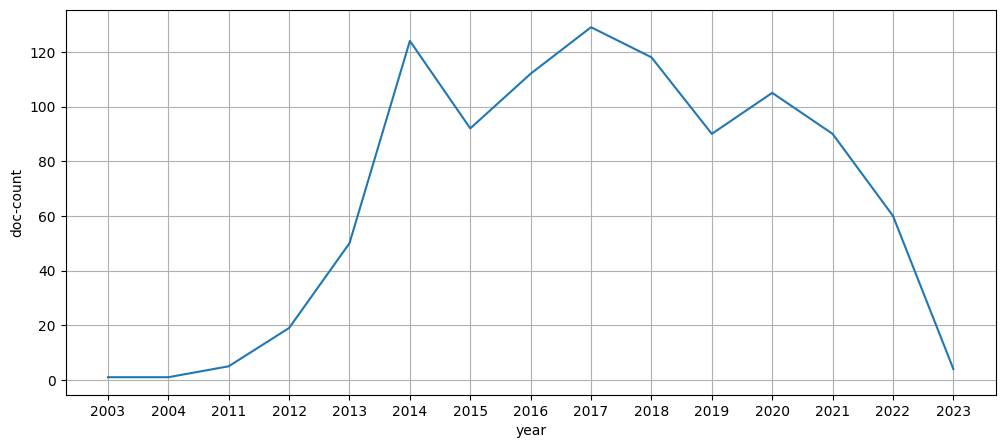

In [30]:
#크기 조정
plt.figure(figsize = (12, 5))
plt.xlabel("year")
plt.ylabel("doc-count")
#격자무늬 생성
plt.grid(True)
#x축: summary_year의 연도, y축: summary_year(데이터 프레임)의 연도별 출판 개수
plt.plot(range(len(summary_year)), summary_year['doc_count'])

#x축 네이밍
plt.xticks(range(len(summary_year)), [text for text in summary_year['출판일']])
plt.show()

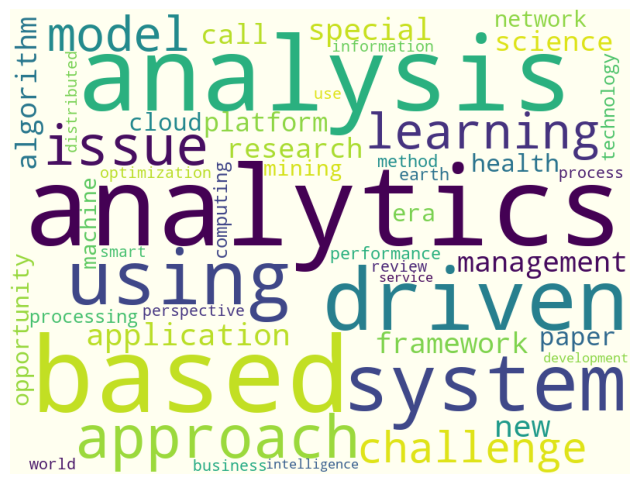

In [29]:
stopwords = set(STOPWORDS)
wc = WordCloud(background_color = 'ivory', stopwords = stopwords,width = 800, height = 600)
cloud = wc.generate_from_frequencies(word_count)
plt.figure(figsize = (8,8))
plt.imshow(cloud)
plt.axis('off')
plt.show()

In [30]:
cloud.to_file("8장_data/riss_bigdata_wordCloud.jpg")

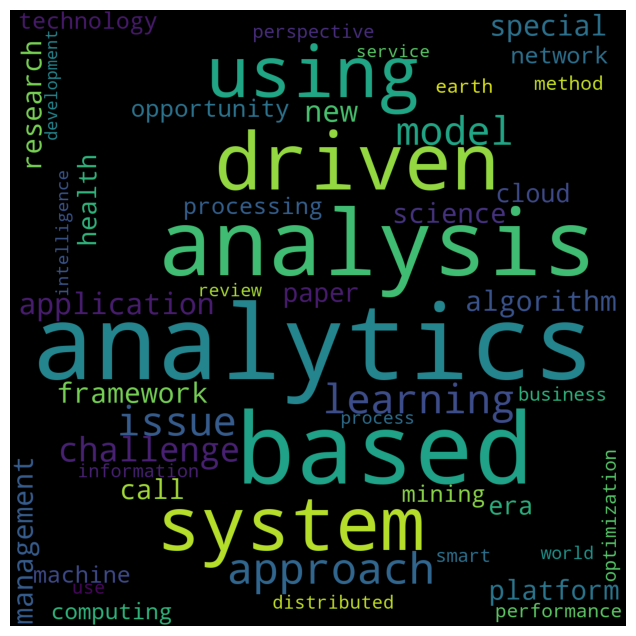

In [ ]:
#실습
# 특정 이미지 형태로 그리는 것 추가해보기
# 원 형태의 이미지를 따와서 그려보는 실습 진행
stopwords = set(STOPWORDS)
image = np.array(Image.open('./8장_data/circle-576797_1280.png'))
wc = WordCloud(background_color = 'black', stopwords = stopwords,mask = image, width = 800, height = 800)
cloud = wc.generate_from_frequencies(word_count)

plt.figure(figsize = (8,8))
plt.imshow(cloud)

#눈금선 삭제
plt.axis('off')
plt.show()

## ---------------------------------------------
<추가 문제>
- 시간이 되는 사람은 news_category_dataset 이용하여
- news 카테고리 별로 정렬하여 wordcloud 생성
- 추가 과제 사진, 과제 파일: ptc_08news_category.ipynb 참고
## ---------------------------------------------

import 부분

In [6]:
import pandas as pd
import glob
import re
from functools import reduce
import json

#토크나이저 모듈
from nltk.tokenize import word_tokenize
#불용어 처리
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
#단어 빈도 분석
from collections import Counter
#시각화
import matplotlib.pyplot as plt
#워드클라우드 시각화 모듈
from wordcloud import STOPWORDS, WordCloud

#word cloud를 위해 이미지를 불러오는데 사용
import numpy as np
from PIL import *
import random

사진 처리 부분

In [12]:
! pip install rembg Pillow

  Using cached rembg-2.0.69-py3-none-any.whl.metadata (17 kB)
  Using cached jsonschema-4.25.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached opencv_python_headless-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached pymatting-1.1.14-py3-none-any.whl.metadata (7.7 kB)
  Using cached scikit_image-0.25.2-cp313-cp313-win_amd64.whl.metadata (14 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached numba-0.63.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2025.10.16-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
Using cac

ERROR: Could not install packages due to an OSError: [WinError 32] 다른 프로세스가 파일을 사용 중이기 때문에 프로세스가 액세스 할 수 없습니다: 'C:\\Users\\user\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\numba\\core\\cgutils.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
   ---------------------- ----------------- 21.5/38.9 MB 106.7 MB/s eta 0:00:01
   ------------------------------- -------- 30.4/38.9 MB 74.1 MB/s eta 0:00:01
   ---------------------------------------  38.8/38.9 MB 73.1 MB/s eta 0:00:01
   ---------------------------------------- 38.9/38.9 MB 61.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------- ----- 11.0/12.6 MB 53.6 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 35.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 68.3 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------- ----------------- 21.2/38.1 MB 104.8 MB/s eta 0:00:01
   -------------------------------- ------- 30.7/38.1 MB 83.1 MB/s eta 0:00:01
   ----------------

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
! pip install onnxruntime

   ---------------------------------------- 0.0/13.5 MB ? eta -:--:--
   ------------------ --------------------- 6.3/13.5 MB 32.4 MB/s eta 0:00:01
   ---------------------------------------- 13.5/13.5 MB 37.9 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 84.3 MB/s  0:00:00
   ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
   ---------------------------------------- 536.2/536.2 kB 35.1 MB/s  0:00:00

   ---------------------------------------- 0/8 [mpmath]
   ---------------------------------------- 0/8 [mpmath]
   ---------------------------------------- 0/8 [mpmath]
   ---------------------------------------- 0/8 [mpmath]
   ---------------------------------------- 0/8 [mpmath]
   ---------------------------------------- 0/8 [mpmath]
   ---------------------------------------- 0/8 [mpmath]
   ----- ---------------------------------- 1/8 [flatbuffers]
   ---------- --------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from rembg import remove
from PIL import Image
import os

input_path = './8장_data/mokoko.png'
output_path = './8장_data/mokoko-removebg.png'

try:
    # 1. 입력 이미지 열기
    if not os.path.exists(input_path):
        print(f"오류: 입력 파일 '{input_path}'를 찾을 수 없습니다.")
    else:
        input_img = Image.open(input_path)
        print(f"'{input_path}' 이미지 불러오기 완료.")

        # 2. 배경 제거 (가장 핵심적인 부분)
        output_img = remove(input_img)
        print("배경 제거 처리 완료.")

        # 3. 결과 저장
        # PNG 파일로 저장해야 투명 배경이 보존됩니다.
        output_img.save(output_path)
        print(f"배경이 제거된 이미지가 '{output_path}'에 저장되었습니다.")

except Exception as e:
    print(f"처리 중 오류가 발생했습니다: {e}")

'./8장_data/mokoko.png' 이미지 불러오기 완료.


100%|########################################| 176M/176M [00:00<00:00, 411GB/s]


배경 제거 처리 완료.
배경이 제거된 이미지가 './8장_data/mokoko-removebg.png'에 저장되었습니다.


실제 코드

trump : 14418
photo : 12446
new : 9008
video : 6283
say : 5840
day : 5500
u : 5329
woman : 5261
year : 4976
donald : 4849
make : 4496
get : 4434
way : 4141
best : 3899
life : 3736
world : 3463
time : 3429
one : 3402
show : 3385
kid : 3282
people : 3065
thing : 2996
week : 2980
first : 2942
like : 2851
love : 2777
need : 2714
want : 2682
american : 2658
obama : 2611
child : 2567
look : 2559
could : 2553
man : 2454
home : 2408
health : 2394
house : 2386
take : 2361
know : 2360
wedding : 2307
black : 2302
star : 2275
right : 2254
mom : 2239
back : 2236
america : 2219
clinton : 2199
state : 2196
gop : 2163
food : 2155
help : 2149
may : 2119
white : 2103
go : 2102
school : 2041
family : 2005
gay : 1976
watch : 1936
find : 1927
top : 1927
baby : 1908
bill : 1889
call : 1854
change : 1835
study : 1801
old : 1786
president : 1727
police : 1712
good : 1712
parent : 1700
girl : 1690
hillary : 1669
republican : 1655
tip : 1647
death : 1644
report : 1610
big : 1602
recipe : 1581
war : 1552
really 

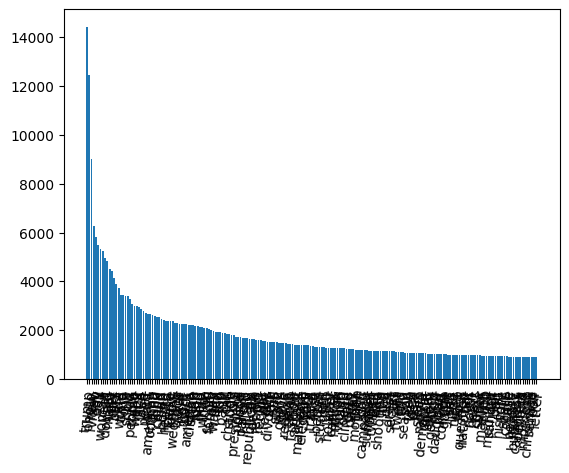

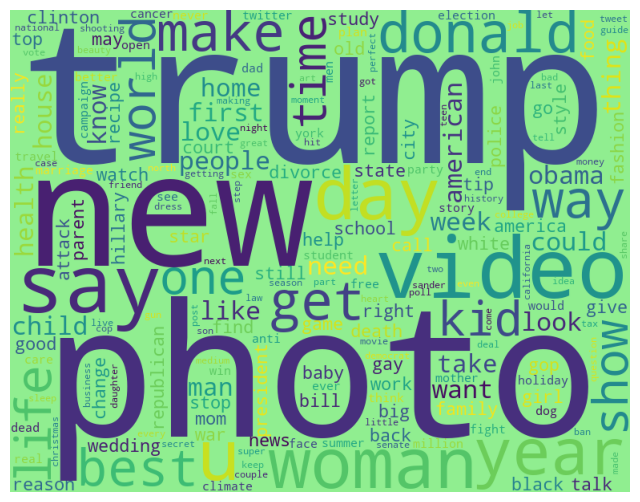

In [17]:
# file = json.loads(open('./8장_data/News_Category_Dataset_v3.json', 'r', encoding = 'utf-8').read())
# lst_data = []
# for f in file:
#     data_f = pd.read_json(f, lines=True) #라인별로 읽어들이도록(1라인 1Json객체) lines 조건 추가
#     lst_data.append(data_f)
lst_data  = pd.read_json('./8장_data/News_Category_Dataset_v3.json', lines = True)
# lst_data #표 확인, lst_data[0] 안에 모든 데이터 들어있음

titles = lst_data['headline']
# titles

stopWords = set(stopwords.words("english"))
lemma = WordNetLemmatizer() #어간 추출기(레마)

words = []
for title in titles:
    #정규식 사용, 알파벳 제외한 모든 것 공백으로 치환
    EnWords = re.sub(r"[^a-zA-Z]+", " ", str(title))
    
    #소문자로 모두 변환 후 단어 분리
    EnWordsToken = word_tokenize(EnWords.lower())
    
    #EnwordsToken에 있는 모든 요소들에 대하여 각 요소들이 stopWords에 있지 않다면 리스트에 넣어라
    EnWordsTokenStop = [ w for w in EnWordsToken if w not in stopWords]
    
    #lemmatize : 단어 형태를 원형으로 변환
    EnWordsTokenStopLemma = [ lemma.lemmatize(w) for w in EnWordsTokenStop]
    words.append(EnWordsTokenStopLemma)

words_r = [w for row in words for w in row]
# words_r
count = Counter(words_r)
# count

word_count = dict()
for tag, counts in count.most_common(200):
    if(len(str(tag))):
        word_count[tag] = counts
        print(tag, ":", counts)
        
#텍스트 빈도 분석: 어떤 글자가 몇 번씩 나왔는지
sorted_keys = sorted(word_count, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count.values(), reverse = True)

#차트에 데이터 삽입
plt.bar(range(len(word_count)), sorted_Values, align = 'center')
plt.xticks(range(len(word_count)), list(sorted_keys), rotation = 85)
plt.show()

#wordcloud 제작 - 아무 이미지 가져다가 깨끗하게 배경 따서 이용하면 됨
stopWords = set(STOPWORDS)
mokoko = np.array(Image.open('./8장_data/mokoko.png'))
wc = WordCloud(background_color = 'lightgreen', stopwords = stopwords, width = 800, height = 600, mask = mokoko)
cloud = wc.generate_from_frequencies(word_count)

plt.figure(figsize = (8,8))
plt.imshow(cloud)

#눈금 삭제
plt.axis('off')
plt.show()